Task 1 : Data Loading & Exploration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
print("Shape of dataset:",df.shape)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Shape of dataset: (545, 13)
Number of rows: 545
Number of columns: 13


In [6]:
print("Column names:", df.columns.tolist())

Column names: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [7]:
target = 'price'
features = [col for col in df.columns if col != target]
print("Target column:", target)
print("\nFeature columns:")
for f in features:
    print("  →", f)

Target column: price

Feature columns:
  → area
  → bedrooms
  → bathrooms
  → stories
  → mainroad
  → guestroom
  → basement
  → hotwaterheating
  → airconditioning
  → parking
  → prefarea
  → furnishingstatus


In [8]:
print("Missing values in each column:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Data types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
text_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                'airconditioning', 'prefarea', 'furnishingstatus']
for col in text_columns:
    print(f"{col}: {df[col].unique()}")

mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


Task 2 : Data Cleaning

In [11]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [12]:
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[binary_columns] = df[binary_columns].replace({'yes': 1, 'no': 0})

/tmp/ipykernel_3324/2214102357.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_columns] = df[binary_columns].replace({'yes': 1, 'no': 0})


In [13]:
df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished


In [14]:
df = pd.get_dummies(df,columns=['furnishingstatus'],drop_first=True)
print("One-hot encoding done")

One-hot encoding done


In [15]:
print("New columns:", df.columns.tolist())
print("New shape:", df.shape)

New columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']
New shape: (545, 14)


In [16]:
print("Checking for any non-numeric columns?")
print(df.select_dtypes(include='object').columns.tolist())

Checking for any non-numeric columns?
[]


Task 3 : Model Building


In [17]:
from sklearn.model_selection import train_test_split

X=df.drop("price",axis=1)
Y=df['price']

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

print("Training data:",X_train.shape)
print("Testing data:",X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)
lr_predictions = lr_model.predict(X_test)

lr_mae = mean_absolute_error(Y_test,lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(Y_test, lr_predictions))
lr_r2 = r2_score(Y_test,lr_predictions)
print("Linear Regression Results:")
print(f"MAE  : {lr_mae:,.0f}")
print(f"RMSE : {lr_rmse:,.0f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Results:
MAE  : 970,043
RMSE : 1,324,507
R²   : 0.6529


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)
rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(Y_test, rf_predictions)
rf_rmse =np.sqrt(mean_squared_error(Y_test,rf_predictions))
rf_r2 =r2_score(Y_test, rf_predictions)
print("Random Forest Results:")
print(f"MAE  : {rf_mae:,.0f}")
print(f"RMSE : {rf_rmse:,.0f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Results:
MAE  : 1,022,560
RMSE : 1,401,497
R²   : 0.6114


In [20]:
print("=" * 45)
print(f"{'Metric':<10}{'Linear Reg':>15}{'Random Forest':>15}")
print("=" * 45)
print(f"{'MAE':<10}{970043:>15,.0f}{1022560:>15,.0f}")
print(f"{'RMSE':<10}{1324507:>15,.0f}{1401497:>15,.0f}")
print(f"{'R²':<10}{0.6529:>15.4f}{0.6114:>15.4f}")
print("=" * 45)
print("\nLinear Regression is better")

Metric         Linear Reg  Random Forest
MAE               970,043      1,022,560
RMSE            1,324,507      1,401,497
R²                 0.6529         0.6114

Linear Regression is better


Task 4 : Visualization

Chart 1: Price Distribution Histogram

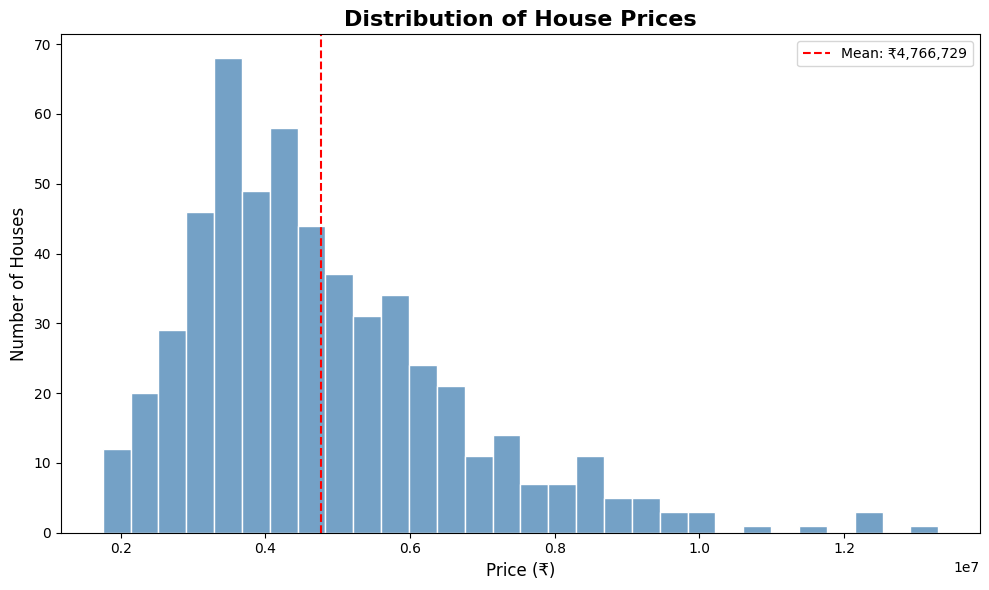

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'],bins=30,color='steelblue',edgecolor='white')

plt.title('Distribution of House Prices', fontsize=16, fontweight='bold')
plt.xlabel('Price (₹)', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)
plt.axvline(df['price'].mean(), color='red', linestyle='--',label=f"Mean: ₹{df['price'].mean():,.0f}")
plt.legend()

plt.tight_layout()
plt.savefig('chart1_price_distribution.png', dpi=150)
plt.show()

Chart 2: Correlation Heatmap

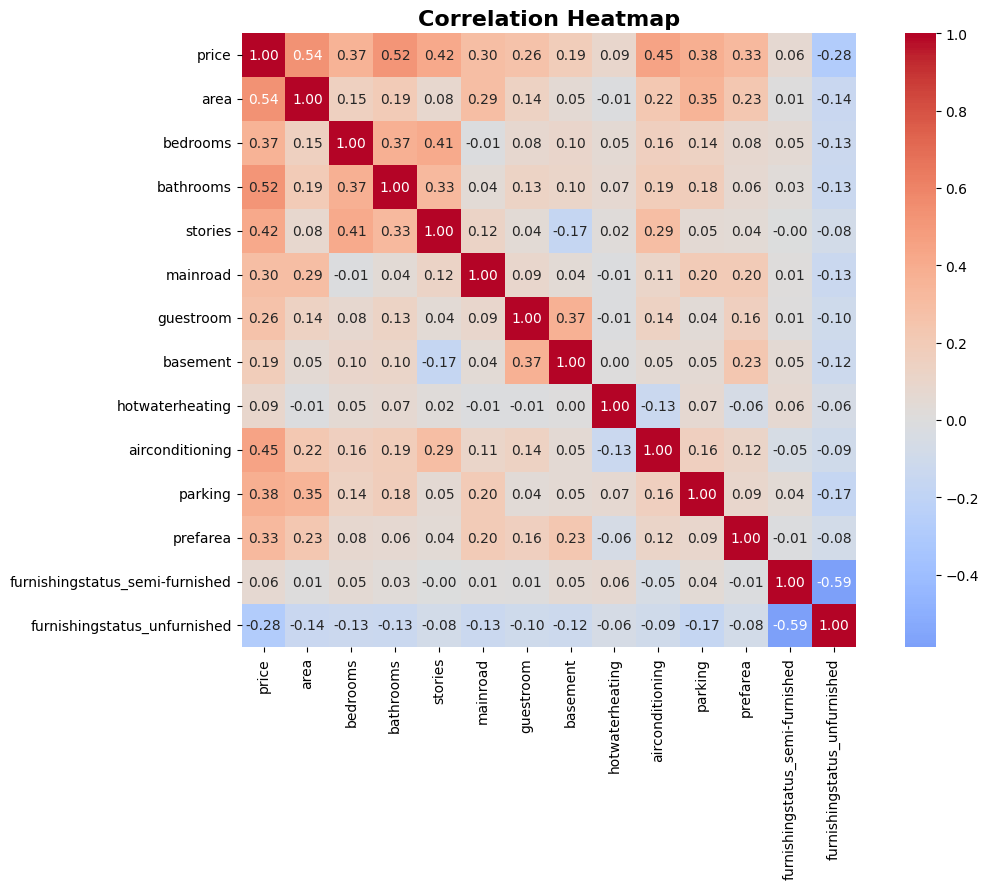

In [23]:
plt.figure(figsize=(12, 9))
correlation = df.corr()
sns.heatmap(correlation,annot=True,fmt='.2f',cmap='coolwarm',center=0,square=True)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_correlation_heatmap.png', dpi=150)
plt.show()

Chart 3: Actual vs Predicted Prices

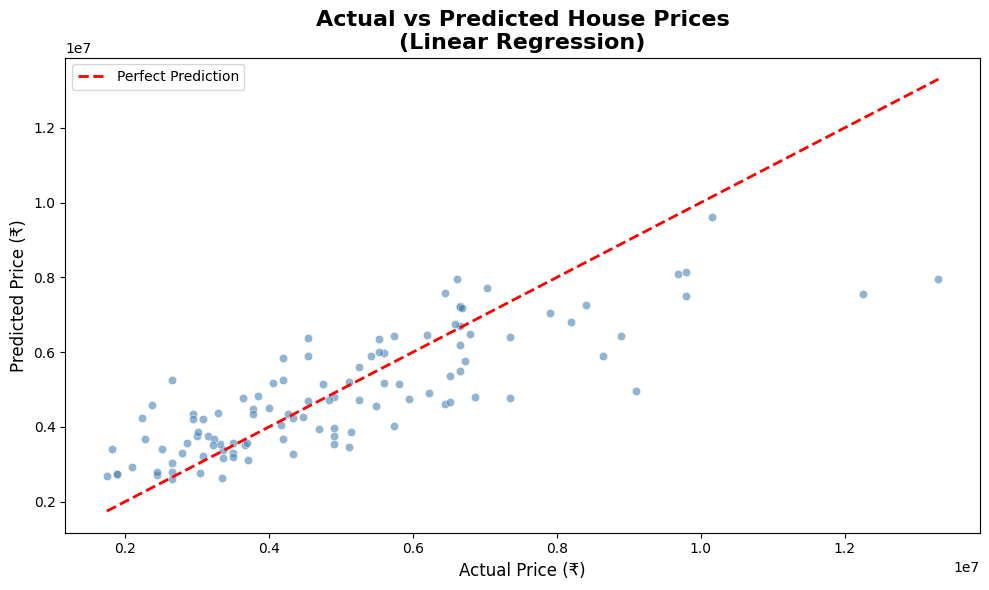

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, lr_predictions,alpha=0.6,color='steelblue',edgecolors='white',linewidth=0.5)

min_val = min(Y_test.min(), lr_predictions.min())
max_val = max(Y_test.max(), lr_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs Predicted House Prices\n(Linear Regression)',fontsize=16, fontweight='bold')
plt.xlabel('Actual Price (₹)', fontsize=12)
plt.ylabel('Predicted Price (₹)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('chart3_actual_vs_predicted.png', dpi=150)
plt.show()

Task 5 : Insights & Summary

### Which features influence house price the most?
Based on the correlation heatmap, the three most influential features are area (0.54), bathrooms (0.52), and airconditioning (0.45). Larger houses with more bathrooms and air conditioning tend to command significantly higher prices in this dataset.

### How accurate was the model?
The Linear Regression model achieved an R² score of 0.65, meaning it can explain 65% of the variation in house prices. On average, predictions were off by around ₹9.7 lakh (MAE). The model performed best on mid-range priced houses but struggled with luxury properties due to very few expensive houses in the training data.

### What was surprising?
Two things stood out. First, hotwaterheating had almost zero correlation (0.09) with price — despite sounding like a premium feature, it barely influences value. Second, the price distribution was heavily right-skewed, with most houses priced under ₹50 lakh but a few luxury properties crossing ₹1 crore, creating a huge gap in the market.

### My recommendation for a real estate business:
Developers and investors should prioritize acquiring and developing
larger properties, as area is the single strongest predictor of house
price. Adding bathrooms and air conditioning can further boost property value significantly.